# 🔋 MGA Exploration Notebook
**Interactive Near-Optimal Solution Exploration for PyPSA Networks**

This notebook allows you to interactively explore the **near-optimal feasible space** of your PyPSA energy system model.  
Instead of a single cost-optimal solution, you can navigate between alternative solutions that are only slightly more expensive but may differ significantly in structure — differing in renewable capacity mix, emissions, or transmission usage.

**Workflow overview:**

| Step | Description |
|------|-------------|
| 1 | Provide your PyPSA network (define it in the notebook, or load a solved `.nc` file) |
| 2 | Define Properties of Interest (PoIs) |
| 3 | Run the Preparation Phase (once per network) |
| 4 | Navigate interactively to alternative solutions |
| 5 | Traverse the path between solutions |
| 6 | Save the exploration results |

> ⚠️ The preparation phase is computationally intensive and may take several minutes. It only needs to be run **once** — results are saved and reloaded automatically.


---
## Section 1 — Setup

In [13]:
import logging
import warnings
logging.getLogger("linopy").setLevel(logging.WARNING)
logging.getLogger("pypsa").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=UserWarning, module="linopy")

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# ── USER CONFIGURATION ──────────────────────────────────────────
network_source = "A"   # "A" = define the network in this notebook (Option A)
                       # "B" = load a solved .nc file (Option B)
# ────────────────────────────────────────────────────────────────

### 1.1 Provide Your Network

There are **two ways** to provide a network. Choose one by setting `network_source` in the
setup cell above (`"A"` or `"B"`), then run **both** cells below — only the selected option
executes; the other prints a note and does nothing.

- **Option A — Define the network in this notebook (most common).** Build it with plain
  PyPSA code in the next cell. It ships with the example 5-bus network so it runs out of the
  box; edit it to describe your own system. This is the path most users take — everything,
  including the preparation phase, runs from here.
- **Option B — Load a solved `.nc` file.** If you already have a solved PyPSA network on
  disk, point `network_path` at it instead.

Both options leave the same things in scope for the rest of the notebook: a solved `network`,
its optimal cost `opt_cost`, the near-optimality threshold `epsilon`, and a `build_network()`
factory (which Section 3's preparation phase calls to build fresh networks).

> ℹ️ **You never have to run anything outside this notebook.** The heavy *preparation phase*
> (Section 3) runs here too, on the network you provide, and caches its result to
> `data/preparation_state.nc`. The first run computes it; later runs just load the cache. If
> you change the network or the PoIs, flip the `rerun_preparation` switch in Section 3.

In [14]:
# ══════════════════════════════════════════════════════════════════
#  OPTION A — Define the network in this notebook  (most common)
#  Runs only when network_source == "A" (set in the Section 1 setup
#  cell); otherwise it prints a note and does nothing.
#
#  build_network() below is a 5-bus example with five generation carriers
#  (solar, wind, hydro, biomass, gas), in plain PyPSA so you can read and edit it.
#  It is a FUNCTION because the preparation phase (Section 3) calls it repeatedly
#  to build fresh networks as it samples.
#
#  ⚠ TO EXPLORE YOUR OWN NETWORK: edit the body of build_network() (buses,
#  generators, lines, loads — keep `p_nom_extendable=True` and meaningful
#  `carrier` names, since Section 2's PoIs are built from carriers). Then make
#  Section 2's poi_definitions match your carriers and re-run Section 3's
#  preparation cell (set rerun_preparation=True). It all stays in the notebook.
# ══════════════════════════════════════════════════════════════════

import numpy as np
import pypsa

if network_source != "A":
    print('network_source != "A" — skipping Option A (define the network in-notebook).')
else:
    # ── USER CONFIGURATION ──────────────────────────────────────────
    epsilon = 0.05                  # near-optimality threshold for preparation (5% above optimum)
    N_SNAPSHOTS = 72                # 3 representative days
    # ────────────────────────────────────────────────────────────────

    def build_network():
        """Build and return the (unsolved) network. Edit this to define your own."""
        n = pypsa.Network()
        n.set_snapshots(range(N_SNAPSHOTS))
        n.snapshot_weightings[:] = 8760 / N_SNAPSHOTS   # scale weights to one year

        # --- buses ---
        for bus in ("north", "south", "east", "west", "center"):
            n.add("Bus", bus, carrier="AC")

        # --- lines (finite capacity -> spatial trade-offs; small r avoids a warning) ---
        for name, b0, b1, s in [
            ("center-north", "center", "north", 1500.0),
            ("center-south", "center", "south", 1500.0),
            ("center-east",  "center", "east",  1500.0),
            ("center-west",  "center", "west",  1500.0),
            ("north-east",   "north",  "east",  1000.0),
            ("south-west",   "south",  "west",  1000.0),
        ]:
            n.add("Line", name, bus0=b0, bus1=b1, s_nom=s, x=0.01, r=0.001, carrier="AC")

        # --- per-snapshot capacity factors ---
        h = np.arange(N_SNAPSHOTS); hod = h % 24
        solar_cf     = np.clip(np.sin(np.pi * (hod - 6) / 12), 0, 1)
        wind_cf      = np.clip(0.35 + 0.20*np.sin(2*np.pi*h/24 + 1.0) + 0.10*np.sin(2*np.pi*h/(24*3)), 0.02, 1)
        wind_cf_west = np.clip(wind_cf * 1.3, 0, 1)         # west is windier (offshore-like)
        hydro_cf     = np.clip(0.50 + 0.08*np.sin(2*np.pi*h/(24*3)), 0, 1)

        # --- generators (extendable; the `carrier` names drive Section 2's PoIs) ---
        for bus in ("north", "south", "east", "west"):
            n.add("Generator", f"solar_{bus}", bus=bus, carrier="solar", p_nom_extendable=True,
                  capital_cost=55_000, marginal_cost=0.0, p_max_pu=solar_cf)
        n.add("Generator", "wind_north",  bus="north",  carrier="wind", p_nom_extendable=True,
              capital_cost=90_000, marginal_cost=0.0, p_max_pu=wind_cf)
        n.add("Generator", "wind_center", bus="center", carrier="wind", p_nom_extendable=True,
              capital_cost=90_000, marginal_cost=0.0, p_max_pu=wind_cf)
        n.add("Generator", "wind_west",   bus="west",   carrier="wind", p_nom_extendable=True,
              capital_cost=90_000, marginal_cost=0.0, p_max_pu=wind_cf_west)
        for bus in ("south", "east"):
            n.add("Generator", f"hydro_{bus}", bus=bus, carrier="hydro", p_nom_extendable=True,
                  capital_cost=110_000, marginal_cost=0.0, p_max_pu=hydro_cf)
        for bus in ("center", "south"):     # biomass: dispatchable, moderate fuel cost
            n.add("Generator", f"biomass_{bus}", bus=bus, carrier="biomass", p_nom_extendable=True,
                  capital_cost=70_000, marginal_cost=25.0)
        for bus in ("center", "north"):     # gas: cheap to build, expensive peaker (backup)
            n.add("Generator", f"gas_{bus}", bus=bus, carrier="gas", p_nom_extendable=True,
                  capital_cost=25_000, marginal_cost=70.0)

        # --- loads [MW] (total 4000) ---
        for bus, mw in [("north", 800), ("south", 1000), ("east", 700), ("west", 600), ("center", 900)]:
            n.add("Load", f"load_{bus}", bus=bus, p_set=mw)

        n.sanitize()
        return n

    print("Defining and solving network in notebook ...")
    print()

    network  = build_network()
    network.optimize(solver_name="highs", include_objective_constant=False)
    opt_cost = network.objective

    print()
    print("─" * 40)
    print("  Network Summary")
    print("─" * 40)
    print(f"  {'Buses':<20} {len(network.buses)}")
    print(f"  {'Generators':<20} {len(network.generators)}")
    print(f"  {'Storage units':<20} {len(network.storage_units)}")
    print(f"  {'Lines':<20} {len(network.lines)}")
    print(f"  {'Carriers':<20} {', '.join(sorted(network.generators.carrier.unique()))}")
    print(f"  {'Optimal TOTEX':<20} €{opt_cost/1e6:,.1f}M / yr")
    print(f"  {'Epsilon (ε)':<20} {epsilon*100:.0f}%")
    print(f"  {'TOTEX budget':<20} €{opt_cost*(1+epsilon)/1e6:,.1f}M / yr")
    print("─" * 40)
    print("  ✓ Network defined and solved successfully (Option A).")

Defining and solving network in notebook ...


────────────────────────────────────────
  Network Summary
────────────────────────────────────────
  Buses                5
  Generators           13
  Storage units        0
  Lines                6
  Carriers             biomass, gas, hydro, solar, wind
  Optimal TOTEX        €939.6M / yr
  Epsilon (ε)          5%
  TOTEX budget         €986.6M / yr
────────────────────────────────────────
  ✓ Network defined and solved successfully (Option A).


In [15]:
# ══════════════════════════════════════════════════════════════════
#  OPTION B — Load a solved network from a .nc file
#  Runs only when network_source == "B" (set in the Section 1 setup
#  cell); otherwise it prints a note and does nothing.
# ══════════════════════════════════════════════════════════════════

import pypsa

if network_source != "B":
    print('network_source != "B" — skipping Option B (load a solved .nc file).')
else:
    # ── USER CONFIGURATION ──────────────────────────────────────────
    network_path = "data/network.nc"   # <-- change this to your file path
    epsilon      = 0.05                # near-optimality threshold for preparation
    # ────────────────────────────────────────────────────────────────

    network  = pypsa.Network(network_path)
    opt_cost = network.objective

    # Section 3's preparation builds fresh networks; expose the same build_network()
    # factory Option A provides, here as a copy of the loaded network.
    def build_network():
        return network.copy()

    print(f"Loaded solved network from: {network_path}")
    print()
    print("─" * 40)
    print("  Network Summary")
    print("─" * 40)
    print(f"  {'Buses':<20} {len(network.buses)}")
    print(f"  {'Generators':<20} {len(network.generators)}")
    print(f"  {'Storage units':<20} {len(network.storage_units)}")
    print(f"  {'Lines':<20} {len(network.lines)}")
    print(f"  {'Optimal TOTEX':<20} €{opt_cost/1e6:,.1f}M / yr")
    print(f"  {'Epsilon (ε)':<20} {epsilon*100:.0f}%")
    print(f"  {'TOTEX budget':<20} €{opt_cost*(1+epsilon)/1e6:,.1f}M / yr")
    print("─" * 40)
    print("  ✓ Network loaded successfully (Option B).")

network_source != "B" — skipping Option B (load a solved .nc file).


---
## Section 2 — Define Properties of Interest (PoIs)

**Properties of Interest (PoIs)** are the solution metrics you want to explore — here, the
installed capacity of a generation carrier (solar, wind, …). You define them right in this
notebook as a small list.

Under the hood each PoI needs **two** representations of the same quantity, which is the
fiddly part:
- `evaluate(network)` — compute the value from a *solved* network (here: sum of `p_nom_opt`).
- `linopy_expr(model)` — the same quantity as a Linopy expression (here: sum of the
  `Generator-p_nom` variable), so the engine can *optimize* over it (e.g. the 2D projection
  in Section 3.2).

You don't write those by hand. You list **what** you want; the builder `capacity_poi` in
`mga_engine/poi.py` produces both representations from a `carrier` name (and converts MW→GW).
Each entry below is keyword arguments to that builder:

```python
{"carrier": "solar", "name": "solar_cap_gw", "unit": "GW"}
```

> ⚠️ **PoIs are fixed at preparation time.** The loaded `P_all` (Section 3) has one row per
> PoI, in this order. The set and order here must match what preparation was run with —
> Section 3 checks this and errors out on a mismatch. To change PoIs, edit the list **and**
> re-run preparation in the notebook (set `rerun_preparation = True` in Section 3). To add
> one, the `carrier` must exist in your network's generators.


In [16]:
from mga_engine.poi import make_poi_specs

# ── Define your PoIs here ────────────────────────────────────────
# Each entry = total installed capacity (GW) of all generators of one carrier.
# make_poi_specs turns each into a PoiSpec via capacity_poi (mga_engine/poi.py),
# which builds the evaluate() + linopy_expr() pair. The set and ORDER must match
# the PoIs preparation was run with (Section 3 verifies this).
#
# Note: gas exists in the network as backup but is NOT made a PoI here — you only
# explore the carriers you list. Add {"carrier": "gas", ...} if you want it too.
poi_definitions = [
    {"carrier": "solar",   "name": "solar_cap_gw",   "unit": "GW"},
    {"carrier": "wind",    "name": "wind_cap_gw",    "unit": "GW"},
    {"carrier": "hydro",   "name": "hydro_cap_gw",   "unit": "GW"},
    {"carrier": "biomass", "name": "biomass_cap_gw", "unit": "GW"},
]

poi_specs = make_poi_specs(network, poi_definitions)
poi_units = {spec.name: spec.unit for spec in poi_specs}   # display units, used by later sections

print(f"✓ {len(poi_specs)} PoIs defined:")
for i, spec in enumerate(poi_specs):
    print(f"  [{i}] {spec.name}  ({spec.unit})")

✓ 4 PoIs defined:
  [0] solar_cap_gw  (GW)
  [1] wind_cap_gw  (GW)
  [2] hydro_cap_gw  (GW)
  [3] biomass_cap_gw  (GW)


---
## Section 3 — Preparation Phase

The preparation phase samples the near-optimal feasible space:
1. **Vertex samples** at the extremes of the PoI space via MP(r)
2. **Interior samples** by progressively tightening the suboptimality bound
3. **GP(pⁱ)** per sample for the cost vector and dual variables

It is the heavy step (many solves — can take a few minutes), and it runs **right here in the
notebook** (`run_preparation`) on the network from Section 1 with the PoIs from Section 2.
The result is cached to a `.nc` file, so the cell below computes it the first time and just
**loads** the cache afterwards. Set `rerun_preparation = True` whenever you change the
network (Section 1) or the PoIs (Section 2).


In [17]:
import os
from mga_engine.poi import make_poi_specs
from mga_engine.preparation_state import run_preparation, save as save_state, load as load_state

# ── USER CONFIGURATION ──────────────────────────────────────────
preparation_state_path = "data/preparation_state.nc"
rerun_preparation      = False   # set True after changing the network (Section 1) or PoIs (Section 2)
# ────────────────────────────────────────────────────────────────

# Run the (heavy) preparation phase the first time, on the Section 1 network and
# the Section 2 PoIs; afterwards just load the cached result.
if rerun_preparation or not os.path.exists(preparation_state_path):
    print("Running preparation phase — this can take a few minutes ...")
    def make_specs(net):
        return make_poi_specs(net, poi_definitions)
    P_all, v, Gamma, solutions, p_star, poi_names = run_preparation(
        build_network, make_specs, epsilon=epsilon)
    save_state(preparation_state_path, P_all, v, Gamma, solutions, p_star, epsilon, poi_names)

state   = load_state(preparation_state_path)
P_all   = state["P_all"]
v       = state["v"]
p_star  = state["p_star"]
epsilon = state["epsilon"]      # authoritative: the epsilon P_all was actually built with

# Global per-PoI extent of the sampled space — used by Sections 3.1, 4.3, and 5.
poi_min = P_all.min(axis=1)
poi_max = P_all.max(axis=1)

# Guard: P_all's rows are PoIs in a fixed order. Confirm Section 2's PoIs match
# the ones the loaded state was built with, so labels and rows line up.
poi_names_saved = state["poi_names"]
if poi_names_saved is not None:
    assert [s.name for s in poi_specs] == poi_names_saved, (
        f"PoIs in Section 2 {[s.name for s in poi_specs]} don't match the preparation "
        f"state {poi_names_saved}. Set rerun_preparation=True, or fix poi_definitions in Section 2."
    )

print()
print("─" * 45)
print("  Preparation Summary")
print("─" * 45)
print(f"  Total samples (P_all):  {P_all.shape[1]}")
print(f"  PoI dimensions (m):     {P_all.shape[0]}")
print(f"  PoIs:                   {', '.join(poi_names_saved) if poi_names_saved else 'unnamed (old state file)'}")
print(f"  TOTEX range:   €{v.min()/1e6:,.1f}M – €{v.max()/1e6:,.1f}M / yr")
print(f"  Epsilon (ε):   {epsilon*100:.0f}%")
print("─" * 45)

[state] Loaded preparation state from data/preparation_state.nc  (80 samples)

─────────────────────────────────────────────
  Preparation Summary
─────────────────────────────────────────────
  Total samples (P_all):  80
  PoI dimensions (m):     4
  PoIs:                   solar_cap_gw, wind_cap_gw, hydro_cap_gw, biomass_cap_gw
  TOTEX range:   €944.3M – €986.6M / yr
  Epsilon (ε):   5%
─────────────────────────────────────────────


### 3.1 Near-Optimal Space Overview

The chart below shows the **min–max range of each PoI** across all sampled near-optimal solutions. This is the space you will explore interactively in the next section.

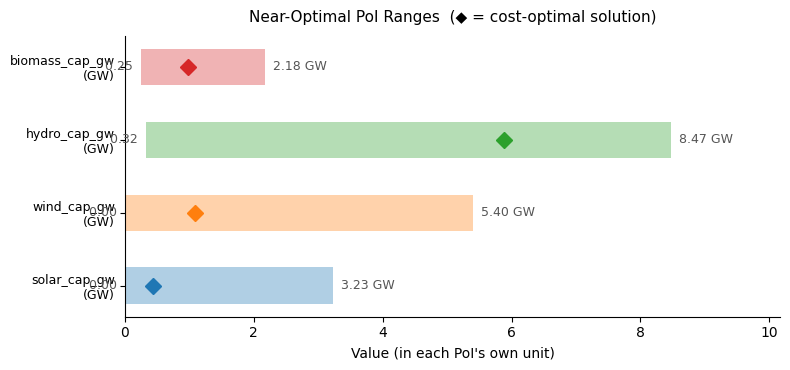

In [18]:
# ── PoI ranges (poi_min/poi_max) from the Section 3 preparation cell ─
fig, ax = plt.subplots(figsize=(8, 0.7 * len(poi_specs) + 1))

colors = plt.cm.tab10.colors
y_pos  = range(len(poi_specs))

for i, spec in enumerate(poi_specs):
    unit = poi_units[spec.name]
    lo, hi = poi_min[i], poi_max[i]
    c = colors[i % len(colors)]
    ax.barh(i, hi - lo, left=lo, height=0.5, color=c, alpha=0.35, label=spec.name)
    ax.plot(p_star[i], i, "D", color=c, markersize=8, zorder=5)
    ax.text(hi, i, f"  {hi:.2f} {unit}", va="center", fontsize=9, color="#555")
    ax.text(lo, i, f"{lo:.2f}  ", va="center", ha="right", fontsize=9, color="#555")

ax.set_yticks(list(y_pos))
ax.set_yticklabels([f"{spec.name}\n({poi_units[spec.name]})" for spec in poi_specs], fontsize=9)
ax.set_xlabel("Value (in each PoI's own unit)", fontsize=10)
ax.set_title("Near-Optimal PoI Ranges  (◆ = cost-optimal solution)", fontsize=11, pad=10)
ax.spines[["top", "right"]].set_visible(False)
ax.margins(x=0.2)
plt.tight_layout()
plt.show()

### 3.2 Near-Optimal Space — 2D Projection

Select two PoIs to use as axes. The shaded region is the **true 2D boundary of the
near-optimal space projected onto that plane**, computed on request by solving MP(r) for
the selected pair (`project_hull`) — not an approximation from sampled points. The diamond
marks the cost-optimal solution. Sample points appearing inside the boundary are genuine:
they sit deeper in the space along the other (hidden) PoI dimensions.

The first time a PoI pair is selected, its projection is solved on request, so there is a
short delay before the plot updates. Previously computed pairs are cached in memory and
render instantly (re-running the cell clears the cache).

In [ ]:
from collections import OrderedDict
from mga_engine.poi import make_poi_specs
from mga_engine.projection import project_hull

poi_names = [spec.name for spec in poi_specs]

# ── Hull cache ───────────────────────────────────────────────────
# LRU cache of project_hull results, keyed by the canonical pair
# (min(i,j), max(i,j)) so (i,j) and (j,i) share one entry. Defined in this
# cell on purpose: re-running the cell resets the cache (the invalidation
# mechanism after changing the network, PoIs, or epsilon).
_hull_cache = OrderedDict()
_HULL_CACHE_MAX = 32

def _hull_for_pair(i, j):
    """Return hull vertices in (PoI_i, PoI_j) column order, via the LRU cache."""
    key = (min(i, j), max(i, j))
    if key in _hull_cache:
        _hull_cache.move_to_end(key)
    else:
        # Fresh network from the Section 1 factory; project_hull builds its own
        # MGA model on it. PoIs use the same poi_definitions as Section 2.
        net_hull = build_network()
        specs_hull = make_poi_specs(net_hull, poi_definitions)
        _hull_cache[key] = project_hull(net_hull, specs_hull, opt_cost, epsilon,
                                        key[0], key[1])
        if len(_hull_cache) > _HULL_CACHE_MAX:
            _hull_cache.popitem(last=False)
    hull = _hull_cache[key]
    # Stored in canonical (min, max) orientation; swap columns if asked for (j, i).
    return hull if i < j else hull[:, ::-1]

# ── Controls ─────────────────────────────────────────────────────
x_sel = widgets.Dropdown(options=poi_names, value=poi_names[0],
                         description="X axis:", style={"description_width": "80px"})
y_sel = widgets.Dropdown(options=poi_names, value=poi_names[-1],
                         description="Y axis:", style={"description_width": "80px"})
out_proj = widgets.Output()

def update_projection(change=None):
    i = poi_names.index(x_sel.value)
    j = poi_names.index(y_sel.value)
    out_proj.clear_output(wait=True)
    with out_proj:
        if i == j:
            print("Please select two different PoIs.")
            return

        hull_xy = _hull_for_pair(i, j)

        fig, ax = plt.subplots(figsize=(6, 5))

        closed = np.vstack([hull_xy, hull_xy[0]])
        ax.plot(closed[:, 0], closed[:, 1], color="#2C6EBA", lw=2, zorder=2,
                label="Near-optimal boundary (2D projection)")
        ax.fill(closed[:, 0], closed[:, 1], color="#4C8EDA", alpha=0.12, zorder=1)

        ax.scatter(P_all[i], P_all[j], c="#4C8EDA", alpha=0.45, s=28, zorder=2,
                   label="Sample points (preparation state)")
        ax.plot(p_star[i], p_star[j], "D", color="#E07B54", ms=10, zorder=5,
                label="Cost-optimal solution")

        ax.set_xlabel(f"{x_sel.value} ({poi_units[x_sel.value]})", fontsize=10)
        ax.set_ylabel(f"{y_sel.value} ({poi_units[y_sel.value]})", fontsize=10)
        ax.set_title("Near-Optimal Space — 2D Projection (true boundary)", fontsize=11, pad=10)
        ax.legend(fontsize=9, loc="best")
        ax.spines[["top", "right"]].set_visible(False)
        plt.tight_layout()
        plt.show()

x_sel.observe(update_projection, names="value")
y_sel.observe(update_projection, names="value")
display(widgets.HBox([x_sel, y_sel]))
display(out_proj)
update_projection()

Output()

---
## Section 4 — Navigation

Set your preferences for the next solution by editing the `request` dictionary below.

Each entry maps a **PoI name** to a `(direction, delta)` tuple:

- **direction** — `"increase"`, `"decrease"`, or `"keep"`
- **delta (δ)** — desired magnitude of change, in that PoI's own unit (ignored for `"keep"`)

**Priority is the dictionary order:** the first entry is the highest priority, the
next is second, and so on. Any PoI you leave out is treated as `"keep"`.

Since this is plain Python, you can build the request however you like — with a
literal, a loop, or values computed from the network. The notebook converts it into
`navigate()`'s `(τ, S_G, S_L, S_E, δ)` inputs.

Two engine details this conversion has to get right:
- `navigate()` works from the **loaded preparation state** (`P_all`, `v`), starting from
  weights `alpha_s` — the CCP solution at `p_star` (`solve_ccp(p_star, P_all, v)`) — not
  from a live network solve.
- `navigate()` uses an **APoI index** where `0` = cost and `1..m` = PoIs, while
  `poi_specs`/`P_all` use 0-based PoI indexing. The conversion below offsets PoI indices
  by `+1`; `delta` has length `m+1` (slot 0 is cost, always unused since cost is handled
  implicitly by the algorithm's final cost-minimisation step).


### 4.1 Navigation Request & Result

Edit the `request` dictionary below (format and priority rules are described in the
Section 4 intro above), then run the cell to compute the target solution and compare it
against the current one.

Navigation request (priority = dict order):
------------------------------------------------
  [1] solar_cap_gw     ▲ increase by 1 GW
  [2] wind_cap_gw      ▼ decrease by 0.5 GW
  [3] hydro_cap_gw     keep
  [4] biomass_cap_gw   keep
------------------------------------------------

TOTEX: €945.10M/yr -> €986.60M/yr  (Δ = €+41.50M/yr)


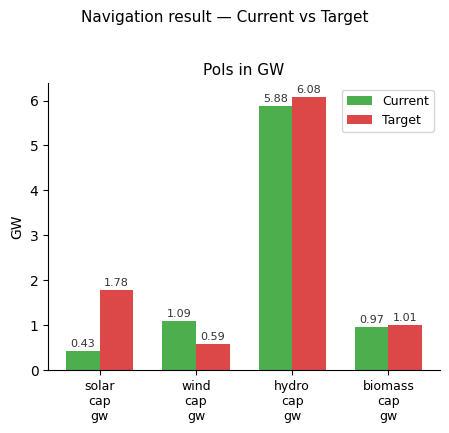

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from mga_engine.ccp_solver import solve_ccp
from mga_engine.navigation import navigate

poi_names = [spec.name for spec in poi_specs]   # 0-based PoI index order, matches P_all rows

# ── Starting point: CCP weights at the cost-optimal PoI vector ───
alpha_s = solve_ccp(p_star, P_all, v)[0]
p_s     = P_all @ alpha_s
cost_s  = float(alpha_s @ v)
current_solution = dict(zip(poi_names, p_s))

# ══════════════════════════════════════════════════════════════════
#  Navigation request — request[<PoI name>] = (<direction>, <delta>).
#  Format and priority rules are described in the Section 4 intro.
# ══════════════════════════════════════════════════════════════════

request = {
    "solar_cap_gw": ("increase", 1.0),
    "wind_cap_gw":  ("decrease", 0.5),
    "hydro_cap_gw": ("keep",     0.0),
    # biomass_cap_gw omitted -> treated as ("keep", 0.0) at lowest priority
}


def build_navigation_inputs(request, poi_names):
    """Convert the request dict into navigate()'s APoI-indexed inputs
    (tau, SG, SL, SE, delta).

    APoI convention: 0 = cost, 1..m = PoIs (offset by +1 from poi_names'
    0-based indexing). Priority (tau) follows dict order; PoIs absent from
    the request are appended as "keep" at the lowest priority, then cost
    (APoI 0) is appended last — it needs no entry in SG/SL/SE since
    navigate() minimises it implicitly in its final step.
    """
    name_to_apoi = {name: i + 1 for i, name in enumerate(poi_names)}
    SG, SL, SE = set(), set(), set()
    delta = np.zeros(len(poi_names) + 1)
    tau, summary = [], []

    for name, (direction, d) in request.items():
        if name not in name_to_apoi:
            raise ValueError(
                f"Unknown PoI {name!r}. Valid names: {', '.join(poi_names)}")
        if direction not in ("increase", "decrease", "keep"):
            raise ValueError(
                f"{name!r}: direction must be increase/decrease/keep, got {direction!r}")
        apoi = name_to_apoi[name]
        tau.append(apoi)
        if direction == "increase":
            SG.add(apoi); delta[apoi] = d
        elif direction == "decrease":
            SL.add(apoi); delta[apoi] = d
        else:
            SE.add(apoi)
        summary.append((name, direction, d if direction != "keep" else 0.0))

    for name, apoi in name_to_apoi.items():
        if apoi not in tau:
            tau.append(apoi); SE.add(apoi)
            summary.append((name, "keep", 0.0))

    tau.append(0)   # cost: lowest priority, handled implicitly
    return tau, SG, SL, SE, delta, summary


tau, SG, SL, SE, delta, summary = build_navigation_inputs(request, poi_names)

print("Navigation request (priority = dict order):")
print("-" * 48)
for prio, (name, direction, d) in enumerate(summary, start=1):
    unit = poi_units.get(name, "")
    if direction == "keep":
        print(f"  [{prio}] {name:<16} keep")
    else:
        arrow = "▲" if direction == "increase" else "▼"
        print(f"  [{prio}] {name:<16} {arrow} {direction} by {d:g} {unit}")
print("-" * 48)

# ── Navigation call ───────────────────────────────────────────────
alpha_t, _, _, _, _, loop1_bounds = navigate(
    P_all, v, alpha_s, tau, SG, SL, SE, delta)
p_t    = P_all @ alpha_t
cost_t = float(alpha_t @ v)
target_solution = dict(zip(poi_names, p_t))

print(f"\nTOTEX: €{cost_s/1e6:,.2f}M/yr -> €{cost_t/1e6:,.2f}M/yr  (Δ = €{(cost_t - cost_s)/1e6:+,.2f}M/yr)")

# ── Current vs Target, grouped by unit so axes stay meaningful ────
unique_units = sorted({poi_units.get(n, "") for n in poi_names})

fig, axes = plt.subplots(1, len(unique_units),
                         figsize=(4.6 * len(unique_units), 4.2))
if len(unique_units) == 1:
    axes = [axes]

for ax, unit in zip(axes, unique_units):
    grp = [n for n in poi_names if poi_units.get(n, "") == unit]
    x = np.arange(len(grp)); width = 0.35
    cur = [current_solution[n] for n in grp]
    tgt = [target_solution[n]  for n in grp]
    b1 = ax.bar(x - width/2, cur, width, label="Current", color="#2CA02C", alpha=0.85)
    b2 = ax.bar(x + width/2, tgt, width, label="Target",  color="#D62728", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([n.replace("_", "\n") for n in grp], fontsize=9)
    ax.set_ylabel(unit, fontsize=10)
    ax.set_title(f"PoIs in {unit}", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    for bars in (b1, b2):
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    f"{bar.get_height():.2f}", ha="center", va="bottom",
                    fontsize=8, color="#333")
    ax.legend(fontsize=9)

plt.suptitle("Navigation result — Current vs Target", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Restricted Region after the First Navigation Loop

This figure shows the space the navigation algorithm **actually searches**: the **sampled
space**, i.e. the convex hull of the stored samples (`P_all`, `v`) — an inner approximation
of the true near-optimal space drawn in Section 3.2. The grey outline is the sampled space
projected onto the two selected APoIs; the shaded region is the same space **intersected
with the bounds fixed by the first loop** of the navigation algorithm (`loop1_bounds` from
the cell above) — the restricted region within which the second loop then optimises, so the
target always lies inside it. Any APoI pair works as axes, including cost.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from mga_engine.alpha_projection import compute_alpha_hull_2d

# Guard: this cell visualizes Section 4.1's navigation result.
assert "loop1_bounds" in globals() and "alpha_t" in globals(), (
    "Run the Section 4.1 navigation cell first — Section 4.2 visualizes its loop-1 bounds.")

# APoI convention (as in Section 4): 0 = cost, 1..m = PoIs. Cost shown in €M/yr.
P_tilde     = np.vstack([v[np.newaxis, :], P_all])
apoi_labels = ["TOTEX (€M/yr)"] + [f"{n} ({poi_units[n]})" for n in poi_names]
apoi_scale  = np.array([1e6] + [1.0] * len(poi_names))   # display divisor per APoI
p_tilde_s   = P_tilde @ alpha_s
p_tilde_t   = P_tilde @ alpha_t

# ── Controls: any APoI pair, default = first two PoIs ────────────
apoi_options = list(zip(apoi_labels, range(len(apoi_labels))))
x_sel_r = widgets.Dropdown(options=apoi_options, value=1,
                           description="X axis:", style={"description_width": "80px"})
y_sel_r = widgets.Dropdown(options=apoi_options, value=2 if len(apoi_options) > 2 else 0,
                           description="Y axis:", style={"description_width": "80px"})
out_restricted = widgets.Output()


def _draw_region(ax, pts, kind, color, label, fill=False):
    """Draw a compute_alpha_hull_2d result: polygon, segment, or single point."""
    if kind == "polygon":
        closed = np.vstack([pts, pts[0]])
        ax.plot(closed[:, 0], closed[:, 1], color=color, lw=2, zorder=2, label=label)
        if fill:
            ax.fill(closed[:, 0], closed[:, 1], color=color, alpha=0.18, zorder=1)
    elif kind == "segment":
        ax.plot(pts[:, 0], pts[:, 1], color=color, lw=3, zorder=2, label=label)
    else:  # "point"
        ax.plot(pts[0, 0], pts[0, 1], "s", color=color, ms=8, zorder=2, label=label)


def update_restricted(change=None):
    ia, ja = x_sel_r.value, y_sel_r.value
    out_restricted.clear_output(wait=True)
    with out_restricted:
        if ia == ja:
            print("Please select two different APoIs.")
            return
        outer_pts, outer_kind = compute_alpha_hull_2d(P_tilde, ia, ja)
        inner_pts, inner_kind = compute_alpha_hull_2d(P_tilde, ia, ja,
                                                      bounds=loop1_bounds)
        sc = np.array([apoi_scale[ia], apoi_scale[ja]])

        fig, ax = plt.subplots(figsize=(6, 5))
        _draw_region(ax, outer_pts / sc, outer_kind, "#888888",
                     "Sampled space")
        _draw_region(ax, inner_pts / sc, inner_kind, "#2C6EBA",
                     "Restricted region (after loop 1)", fill=True)
        ax.plot(p_tilde_s[ia] / sc[0], p_tilde_s[ja] / sc[1], "o", color="#2CA02C",
                ms=9, zorder=5, label="Current solution (α_s)")
        ax.plot(p_tilde_t[ia] / sc[0], p_tilde_t[ja] / sc[1], "o", color="#D62728",
                ms=9, zorder=5, label="Target solution (α_t)")
        ax.set_xlabel(apoi_labels[ia], fontsize=10)
        ax.set_ylabel(apoi_labels[ja], fontsize=10)
        ax.set_title("Restricted region after navigation's first loop\n"
                     "(sampled space — inner approximation of Section 3.2)",
                     fontsize=11, pad=10)
        ax.legend(fontsize=9, loc="best")
        ax.spines[["top", "right"]].set_visible(False)
        plt.tight_layout()
        plt.show()


x_sel_r.observe(update_restricted, names="value")
y_sel_r.observe(update_restricted, names="value")
display(widgets.HBox([x_sel_r, y_sel_r]))
display(out_restricted)
update_restricted()

Output()

### 4.3 Radar Chart — Current → Target

The radar chart overlays the current solution (β = 0) and a solution interpolated
toward the target (β = 1). Each axis is one PoI, normalized to its global min–max range
across the near-optimal space (from the preparation phase). Drag the **β slider** to
watch the solution evolve from current to target.


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Guard: this cell compares Section 4.1's navigation result on the global PoI ranges.
assert "p_s" in globals() and "p_t" in globals(), (
    "Run the Section 4.1 navigation cell first — the radar chart compares its current/target solutions.")
assert "poi_min" in globals() and "poi_max" in globals(), (
    "Run the Section 3 preparation cell first — radar axes are normalized to the global PoI ranges.")

# ── Global PoI ranges (Section 3) and navigation result (Section 4.1) ─
radar_labels = [n.replace("_", "\n") for n in poi_names]
current_vals = p_s
target_vals  = p_t

def normalize(vals):
    return (vals - poi_min) / (poi_max - poi_min)

current_norm = normalize(current_vals)

N      = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

def close_loop(vals):
    v = list(vals)
    return v + v[:1]

# ── beta slider: interpolate current -> target ───────────────────
beta_radar = widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.01,
                description="β (radar):", continuous_update=True,
                style={"description_width": "80px"},
                layout=widgets.Layout(width="500px"))
out_radar = widgets.Output()

def update_radar(change=None):
    beta = beta_radar.value
    interp_vals = current_vals + beta * (target_vals - current_vals)
    interp_norm = normalize(interp_vals)
    out_radar.clear_output(wait=True)
    with out_radar:
        fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))

        ax.plot(angles, close_loop(current_norm), color="#2CA02C", lw=2,
                label="Current (β = 0)")
        ax.fill(angles, close_loop(current_norm), color="#2CA02C", alpha=0.12)

        ax.plot(angles, close_loop(interp_norm), color="#D62728", lw=2, linestyle="--",
                label=f"Interpolated (β = {beta:.2f})")
        ax.fill(angles, close_loop(interp_norm), color="#D62728", alpha=0.18)

        ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=10)
        ax.set_ylim(0, 1)
        ax.set_yticks([0.25, 0.5, 0.75, 1.0])
        ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=7, color="grey")
        ax.set_title("PoI Radar Chart\n(normalized to global min–max range)",
                     fontsize=11, pad=20)
        ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.12), fontsize=9)
        plt.tight_layout()
        plt.show()

beta_radar.observe(update_radar, names="value")
display(beta_radar)
display(out_radar)
update_radar()

FloatSlider(value=0.0, description='β (radar):', layout=Layout(width='500px'), max=1.0, step=0.01, style=Slide…

Output()

---
## Section 5 — Traverse

Once navigation (Section 4) has found a target solution, use the **β slider** to move
along the near-optimal path from the current solution (β = 0, weights `alpha_s`) to the
target (β = 1, weights `alpha_t`).

**Cost vs β.** The top figure plots the **total system cost (TOTEX) along the path** against
β. Its shape comes from the engine's path **breakpoints** (`extract_breakpoints`, Algorithm 2
in `traverse.py`) — the β values where the cost departs from a straight interpolation — so it
is a piecewise-linear curve with a marker at each kink, not a fine β-sampling. The dashed
vertical line and dot show **where you currently are** on the curve and move live as you drag
the slider (`cost_beta` from `solve_ccp`). The grey horizontal reference lines mark the
optimal cost and the ε-max budget; the legend identifies them.

**PoI bars.** For each PoI, the bar shows its **value at the current β**
(`mga_engine.traverse.interpolate`). Each bar carries two horizontal reference lines — the
**start** (β = 0, green dashed) and **target** (β = 1, red dashed) values, identified once in
the legend — which **frame the navigated path**, so the bar always moves between them as you
drag β while they stay put. PoIs are grouped by unit so the axes stay meaningful.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from mga_engine.traverse import interpolate, extract_breakpoints
from mga_engine.ccp_solver import solve_ccp

# Guard: traverse moves along the path from Section 4.1's navigation result.
assert "alpha_s" in globals() and "alpha_t" in globals() and "opt_cost" in globals(), (
    "Run the Section 4.1 navigation cell first — traverse interpolates between its alpha_s and alpha_t.")

# ── Traverse endpoints: start = alpha_s (β=0), target = alpha_t (β=1), from Section 4.1 ─
# Global max per PoI (poi_max) comes from the Section 3 preparation cell and
# sets each subplot's y-top.
unique_units = sorted({poi_units.get(n, "") for n in poi_names})
unit_colors  = dict(zip(unique_units, plt.cm.tab10.colors))

def poi_display_name(name):
    """Tick label for a PoI: 'solar_cap_gw' -> 'Solar' (unit stays on the axis)."""
    base, unit = name, poi_units.get(name, "").lower()
    for suffix in (f"_cap_{unit}", f"_{unit}", "_cap"):
        if len(suffix) > 1 and base.endswith(suffix):
            base = base[: -len(suffix)]
    return base.replace("_", " ").title()

# ── Start (β=0) / target (β=1) PoI vectors — fixed for this path, computed once. ──
p_path_start  = interpolate(P_all, v, alpha_s, alpha_t, 0.0)[0]
p_path_target = interpolate(P_all, v, alpha_s, alpha_t, 1.0)[0]

# ── Cost-vs-β curve nodes from the engine's path breakpoints ─────
#   extract_breakpoints (traverse.py, Algorithm 2) returns the (β, α*) kinks
#   where the CCP cost departs from a straight interpolation by ≥ epsilon_I.
#   The curve joins those kinks plus the two endpoints; cost at a node is v·α
#   (identical to solve_ccp at that β). Path-fixed → computed once, not per tick.
epsilon_I  = 1e6   # €/yr; tighten (e.g. 2e5) for more kinks
SI         = extract_breakpoints(P_all, v, alpha_s, alpha_t, epsilon_I=epsilon_I)
node_betas = np.array([0.0, *[b for b, _ in SI], 1.0])
node_costs = np.array([float(v @ alpha_s),
                       *[float(v @ a) for _, a in SI],
                       float(v @ alpha_t)])
cost_opt   = opt_cost
cost_max   = opt_cost * (1 + epsilon)

# ── beta slider ──────────────────────────────────────────────────
beta_slider = widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.01,
                description="β (path):", continuous_update=True,
                style={"description_width": "80px"},
                layout=widgets.Layout(width="500px"))
out_traverse = widgets.Output()

def update_traverse(change=None):
    beta = beta_slider.value
    p_beta, _ = interpolate(P_all, v, alpha_s, alpha_t, beta)
    _, cost_beta = solve_ccp(p_beta, P_all, v)
    vals_at_beta = dict(zip(poi_names, p_beta))

    out_traverse.clear_output(wait=True)
    with out_traverse:
        # ── Figure 1: TOTEX vs β (piecewise-linear through the path breakpoints) ─
        span = cost_max - cost_opt
        figc, axc = plt.subplots(figsize=(max(6.0, 4.6 * len(unique_units)), 2.8))
        axc.plot(node_betas, node_costs / 1e6, color="#4C8EDA", lw=2, zorder=2)
        axc.scatter(node_betas[1:-1], node_costs[1:-1] / 1e6,
                    color="#4C8EDA", s=40, zorder=3)
        axc.scatter(node_betas[[0, -1]], node_costs[[0, -1]] / 1e6,
                    facecolors="white", edgecolors="#4C8EDA", s=45, zorder=3)
        # budget reference lines — identified in the legend, not by in-plot text
        axc.axhline(cost_opt / 1e6, color="#999", ls=":", lw=1,
                    label="Optimal TOTEX")
        axc.axhline(cost_max / 1e6, color="#999", ls="--", lw=1,
                    label="ε-max budget")
        # live current-β marker
        axc.axvline(beta, color="#1F4E8C", ls="--", lw=1, zorder=1)
        axc.scatter([beta], [cost_beta / 1e6], color="#1F4E8C", s=70, zorder=5)
        axc.annotate(f"€{cost_beta/1e6:.3f}M", (beta, cost_beta / 1e6),
                     textcoords="offset points", xytext=(6, 8),
                     fontsize=8, color="#1F4E8C")
        axc.set_xlim(0, 1)
        axc.set_ylim((cost_opt - 0.05 * span) / 1e6, (cost_max + 0.10 * span) / 1e6)
        axc.set_xlabel("β  (0 = start → 1 = target)", fontsize=9)
        axc.set_ylabel("TOTEX (€M/yr)", fontsize=9)
        axc.set_title(f"TOTEX along the path   (β = {beta:.2f}:  €{cost_beta/1e6:.3f}M/yr)",
                      fontsize=11)
        axc.legend(fontsize=9, loc="best")
        axc.spines[["top", "right"]].set_visible(False)
        plt.tight_layout()
        plt.show()

        # ── Figure 2: PoI bars (unit-grouped) — start/target lines only ─
        fig, axes = plt.subplots(1, len(unique_units),
                                 figsize=(4.6 * len(unique_units), 4.2))
        if len(unique_units) == 1:
            axes = [axes]

        for ax_idx, (ax, unit) in enumerate(zip(axes, unique_units)):
            grp   = [n for n in poi_names if poi_units.get(n, "") == unit]
            x     = np.arange(len(grp))
            vals  = [vals_at_beta[n] for n in grp]
            color = unit_colors[unit]

            bars = ax.bar(x, vals, width=0.55, color=color, alpha=0.85, zorder=2)

            for k, (xi, n) in enumerate(zip(x, grp)):
                i = poi_names.index(n)
                # start (β=0) / target (β=1) — identified once in the legend
                sv, tv = p_path_start[i], p_path_target[i]
                ax.hlines(sv, xi - 0.32, xi + 0.32, color="#2CA02C",
                          lw=1.6, ls="--", zorder=5,
                          label="start (β = 0)" if ax_idx == 0 and k == 0 else None)
                ax.hlines(tv, xi - 0.32, xi + 0.32, color="#D62728",
                          lw=1.6, ls=(0, (4, 2)), zorder=5,
                          label="target (β = 1)" if ax_idx == 0 and k == 0 else None)

            for bar in bars:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                        f"{bar.get_height():.2f}", ha="center", va="bottom",
                        fontsize=9, color="#333", zorder=6)

            ax.set_xticks(x)
            ax.set_xticklabels([poi_display_name(n) for n in grp], fontsize=9)
            ax.set_ylabel(unit, fontsize=10)
            ax.set_title(f"PoIs in {unit}", fontsize=11)
            ax.set_ylim(0, max(poi_max[poi_names.index(n)] for n in grp) * 1.12)
            ax.spines[["top", "right"]].set_visible(False)

        axes[0].legend(fontsize=9, loc="best")
        plt.suptitle(f"Traverse  (β = {beta:.2f})", fontsize=11, y=1.02)
        plt.tight_layout()
        plt.show()

beta_slider.observe(update_traverse, names="value")
display(beta_slider)
display(out_traverse)
update_traverse()

FloatSlider(value=0.0, description='β (path):', layout=Layout(width='500px'), max=1.0, step=0.01, style=Slider…

Output()

---
## Section 6 — Save Results

Bookmark the exploration session from Sections 4–5: the `request` you made, the resulting
current/target PoI values and costs, and the `alpha_s`/`alpha_t` weight vectors — enough to
reconstruct or replot the whole path later (`alpha(β) = (1-β)·alpha_s + β·alpha_t`) without
re-running navigation.

This is a lightweight notebook-level save (`np.savez`), separate from
`mga_engine.preparation_state.save()` — that function persists the whole sample dataset
(`P_all`, `v`, `Gamma`, `solutions`), not a single navigated path, so it isn't the right
shape for this.

In [24]:
import json
import numpy as np

# Guard: this cell bookmarks Section 4.1's navigation request and result.
assert all(name in globals() for name in ("request", "alpha_s", "alpha_t", "cost_s", "cost_t")), (
    "Run the Section 4.1 navigation cell first — saving bookmarks its request and result.")

# ── USER CONFIGURATION ──────────────────────────────────────────
save_path = "data/navigation_path.npz"
# ────────────────────────────────────────────────────────────────

save_btn = widgets.Button(description="💾  Save current exploration",
                button_style="success", layout=widgets.Layout(width="220px"))
out_save = widgets.Output()

def on_save(b):
    out_save.clear_output(wait=True)
    with out_save:
        np.savez(
            save_path,
            alpha_s=alpha_s, alpha_t=alpha_t,
            p_s=p_s, p_t=p_t,
            cost_s=cost_s, cost_t=cost_t,
            poi_names=np.array(poi_names),
            request_json=json.dumps(request),
        )
        print(f"✓ Saved exploration (request, target, alphas) to: {save_path}")

save_btn.on_click(on_save)
display(save_btn)
display(out_save)

Button(button_style='success', description='💾  Save current exploration', layout=Layout(width='220px'), style=…

Output()